# 实践项目 07：惯性传感器活动识别

我们使用 Opportunity 数据集处理后的真实窗口，观察五个身体部位的加速度和角速度，核对采集运行分组，训练统计特征逻辑回归，并用混淆矩阵检查站立、坐、行走和躺卧。

## 任务总览

1. 核对窗口、通道、类别与划分，查看代表波形。
2. 检查 `source_run_id` 是否跨集合，并提取简单时域特征。
3. 只用训练集拟合标准化和逻辑回归，在验证集选择正则化强度。
4. 固定模型后评价测试集，保存混淆矩阵与宏平均 F1。
5. 查看错误窗口，并与配套研究材料的小型 LSTM 结果比较。

同一采集运行内的重叠窗口高度相似，随机打散会造成泄漏。配套没有显式受试者编号，`source_run_id` 只能表示采集运行分组。


In [1]:
from pathlib import Path  # 处理 Kaggle 与本地文件路径
import json  # 读取并保存结果摘要
import numpy as np  # 处理传感器窗口
import matplotlib.pyplot as plt  # 绘制波形和混淆矩阵
from sklearn.pipeline import make_pipeline  # 把标准化和模型放在同一管道中
from sklearn.preprocessing import StandardScaler  # 只从训练数据学习特征尺度
from sklearn.linear_model import LogisticRegression  # 建立可解释的统计特征基线
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix  # 评价四分类结果


def find_file(name):  # 在 Kaggle 数据集或本地项目目录中寻找指定文件
    roots = [Path('/kaggle/input'), Path.cwd(), Path.cwd() / '数据', Path.cwd() / 'data', Path.cwd().parent / '数据', Path.cwd().parent / 'data']  # 同时兼容项目根目录和实践/答案子目录
    for root in roots:  # 遍历可能的数据根目录
        if not root.exists():  # Kaggle 之外的环境可能没有 /kaggle/input
            continue  # 跳过不存在的目录
        matches = list(root.rglob(name))  # 递归查找文件，兼容 Kaggle 自动添加的数据集目录名
        if matches:  # 找到后立即返回第一项
            return matches[0]  # 返回实际文件路径
    raise FileNotFoundError(f'没有找到 {name}，请确认已添加项目数据集。')  # 给出可操作的错误信息

LOCAL_PROJECT = Path.cwd().parent if (Path.cwd().parent / '数据').exists() else Path.cwd()  # 从实践/答案子目录运行时回到项目根目录
OUT = Path('/kaggle/working') if Path('/kaggle/working').exists() else LOCAL_PROJECT / '结果'  # Kaggle 与本地共用输出规则
OUT.mkdir(parents=True, exist_ok=True)  # 确保结果目录存在


bundle = np.load(find_file('smarthar_lite.npz'), allow_pickle=True)  # 读取真实 Opportunity 窗口
X = bundle['X'].astype(np.float32)  # 形状为窗口×时间点×通道
y = bundle['y'].astype(int)  # 四类活动标签
split = bundle['split'].astype(str)  # 训练、验证和测试划分
run_id = bundle['source_run_id'].astype(str)  # 时间戳回退得到的采集运行编号
feature_names = bundle['feature_names'].astype(str)  # 30个传感器通道名称
label_names = np.array(['Stand', 'Sit', 'Walk', 'Lie'])  # 标签编号对应的活动名称
source_metrics = json.loads(find_file('source_metrics.json').read_text(encoding='utf-8'))  # 读取配套基线与 LSTM 指标
print('X:', X.shape, 'y:', y.shape, 'splits:', dict(zip(*np.unique(split, return_counts=True))))  # 核对输入


X: (2999, 90, 30) y: (2999,) splits: {np.str_('test'): np.int64(491), np.str_('train'): np.int64(1952), np.str_('validation'): np.int64(556)}


## 任务 1：窗口、通道与代表波形

输出每个集合的窗口数和类别计数，选择每类一个窗口，绘制背部加速度与角速度。所有子图使用同一时间轴。

参考结果用于理解信号、划分和错误类型，测试集不参与参数选择。


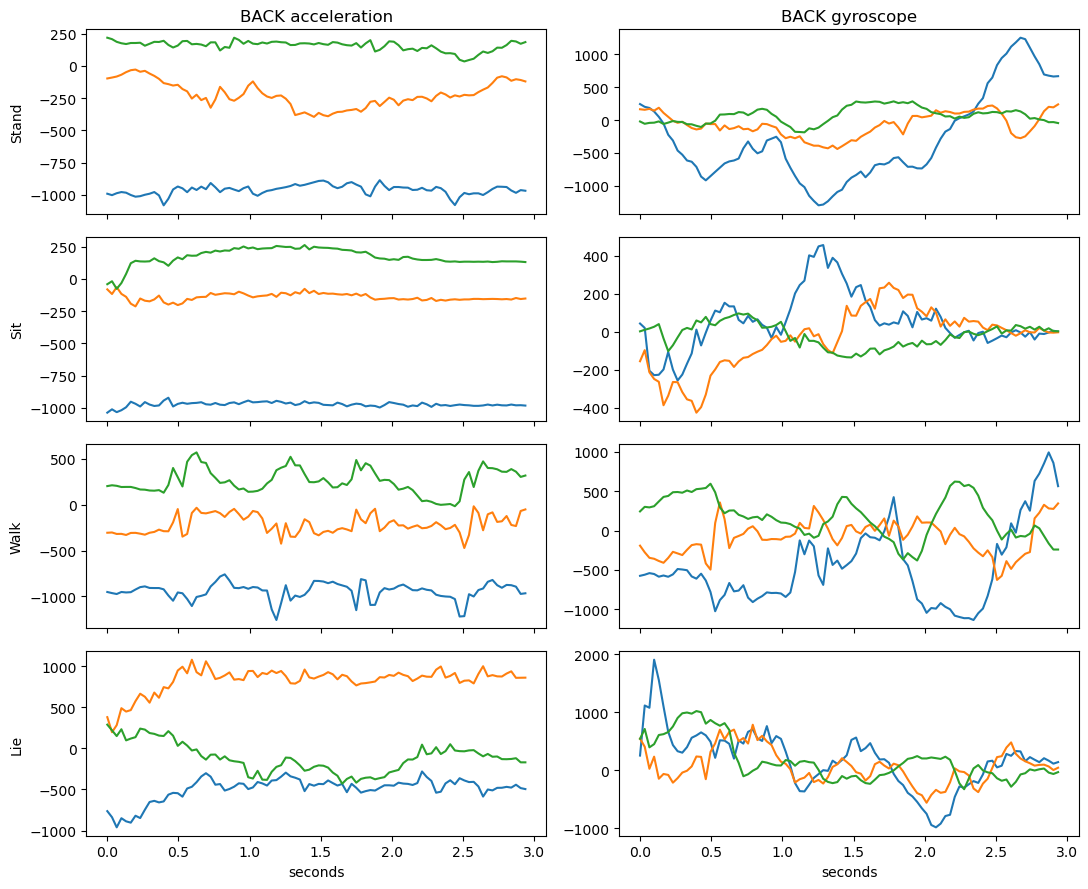

{'train': {'windows': 1952, 'class_counts': [810, 744, 285, 113]}, 'validation': {'windows': 556, 'class_counts': [228, 208, 102, 18]}, 'test': {'windows': 491, 'class_counts': [244, 162, 63, 22]}}


In [2]:
split_summary = {}  # 保存每个集合的窗口数与类别计数
for kind in ['train', 'validation', 'test']:  # 依次核对三个集合
    mask = split == kind  # 选出当前集合窗口
    split_summary[kind] = {'windows': int(mask.sum()), 'class_counts': np.bincount(y[mask], minlength=4).tolist()}  # 统计窗口和类别
fig, axes = plt.subplots(4, 2, figsize=(11, 9), sharex=True)  # 每类显示加速度和角速度
time = np.arange(X.shape[1]) / 30.303  # 把采样点换成秒
for class_id in range(4):  # 依次选择四类活动
    index = np.where(y == class_id)[0][0]  # 选取该类第一个窗口
    axes[class_id, 0].plot(time, X[index, :, 0:3])  # 绘制背部三轴加速度
    axes[class_id, 1].plot(time, X[index, :, 3:6])  # 绘制背部三轴角速度
    axes[class_id, 0].set_ylabel(label_names[class_id])  # 标注活动名称
axes[0, 0].set_title('BACK acceleration')  # 标注左列信号
axes[0, 1].set_title('BACK gyroscope')  # 标注右列信号
axes[-1, 0].set_xlabel('seconds'); axes[-1, 1].set_xlabel('seconds')  # 标注共同时间轴
fig.tight_layout()  # 调整子图间距
fig.savefig(OUT / 'task1_sensor_windows.png', dpi=160)  # 保存代表波形
plt.show()  # 显示波形
print(split_summary)  # 显示核对结果


## 任务 2：分组检查与时域特征

检查训练、验证、测试的 `source_run_id` 交集。对每个通道计算均值、标准差、最小值、最大值和能量，把 `[窗口, 90, 30]` 转为二维特征表。

参考结果用于理解信号、划分和错误类型，测试集不参与参数选择。


In [3]:
groups = {kind: set(run_id[split == kind]) for kind in ['train', 'validation', 'test']}  # 收集每个集合的采集运行编号
overlap = {  # 检查三对集合是否共享采集运行
    'train_validation': sorted(groups['train'] & groups['validation']),
    'train_test': sorted(groups['train'] & groups['test']),
    'validation_test': sorted(groups['validation'] & groups['test']),
}
def window_features(windows):  # 把三维窗口转换成二维统计特征
    mean = windows.mean(axis=1)  # 每通道均值
    std = windows.std(axis=1)  # 每通道标准差
    minimum = windows.min(axis=1)  # 每通道最小值
    maximum = windows.max(axis=1)  # 每通道最大值
    energy = np.mean(windows ** 2, axis=1)  # 每通道平均能量
    return np.concatenate([mean, std, minimum, maximum, energy], axis=1)  # 合并为150维特征
features = window_features(X)  # 为全部窗口提取同一组特征
print({'overlap': overlap, 'feature_shape': features.shape})  # 核对零交集和特征维度


{'overlap': {'train_validation': [], 'train_test': [], 'validation_test': []}, 'feature_shape': (2999, 150)}


## 任务 3：训练集管道与验证集选型

比较 `C=0.1、1、10` 的逻辑回归。标准化和模型只能在训练集拟合，使用验证集宏平均 F1 选择参数。

参考结果用于理解信号、划分和错误类型，测试集不参与参数选择。


In [4]:
train_idx = np.where(split == 'train')[0]  # 取出训练窗口
val_idx = np.where(split == 'validation')[0]  # 取出验证窗口
test_idx = np.where(split == 'test')[0]  # 取出测试窗口
validation_results = []  # 保存三个候选参数的验证表现
best_model, best_c, best_val_f1 = None, None, -1.0  # 初始化最佳模型记录
for c_value in [0.1, 1.0, 10.0]:  # 比较三个正则化强度
    candidate = make_pipeline(StandardScaler(), LogisticRegression(C=c_value, class_weight='balanced', max_iter=1200, random_state=42))  # 建立无泄漏管道
    candidate.fit(features[train_idx], y[train_idx])  # 只使用训练集拟合标准化与模型
    val_pred = candidate.predict(features[val_idx])  # 在验证集产生预测
    val_f1 = f1_score(y[val_idx], val_pred, average='macro')  # 计算验证集宏平均F1
    validation_results.append({'C': c_value, 'macro_f1': float(val_f1)})  # 保存候选结果
    if val_f1 > best_val_f1:  # 根据验证指标更新最佳模型
        best_model, best_c, best_val_f1 = candidate, c_value, float(val_f1)  # 固定最佳设置
print({'selected_C': best_c, 'validation_macro_f1': best_val_f1, 'candidates': validation_results})  # 显示选型依据


{'selected_C': 10.0, 'validation_macro_f1': 0.9030635807557994, 'candidates': [{'C': 0.1, 'macro_f1': 0.896584759578899}, {'C': 1.0, 'macro_f1': 0.8791831155420724}, {'C': 10.0, 'macro_f1': 0.9030635807557994}]}


## 任务 4：测试集评价

参数固定后只评价一次测试集，输出准确率、宏平均 F1 和四分类混淆矩阵。结合每类样本数阅读结果。

参考结果用于理解信号、划分和错误类型，测试集不参与参数选择。


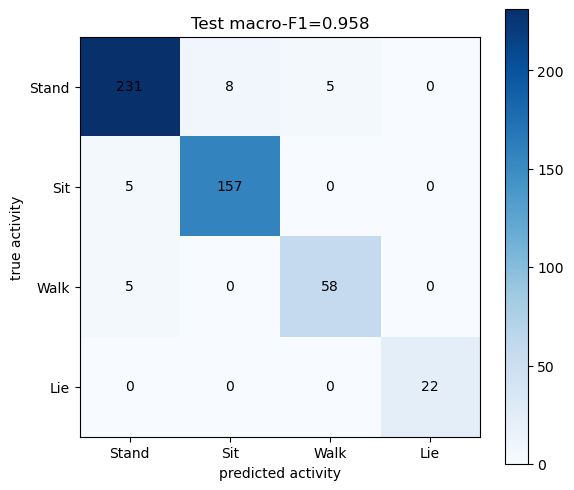

{'accuracy': 0.9531568228105907, 'macro_f1': 0.958364222135148}


In [5]:
test_pred = best_model.predict(features[test_idx])  # 使用固定模型预测独立测试集
test_metrics = {  # 汇总两个主要分类指标
    'accuracy': float(accuracy_score(y[test_idx], test_pred)),  # 计算整体准确率
    'macro_f1': float(f1_score(y[test_idx], test_pred, average='macro')),  # 计算四类等权宏平均F1
}
matrix = confusion_matrix(y[test_idx], test_pred, labels=np.arange(4))  # 固定四类顺序生成混淆矩阵
fig, ax = plt.subplots(figsize=(6, 5.2))  # 创建混淆矩阵图
image = ax.imshow(matrix, cmap='Blues')  # 用颜色表示样本数
for row in range(4):  # 标注每个格子的计数
    for column in range(4):
        ax.text(column, row, int(matrix[row, column]), ha='center', va='center')  # 显示具体数量
ax.set_xticks(range(4), label_names); ax.set_yticks(range(4), label_names)  # 标注活动名称
ax.set(xlabel='predicted activity', ylabel='true activity', title=f"Test macro-F1={test_metrics['macro_f1']:.3f}")  # 标明方向和指标
fig.colorbar(image, ax=ax)  # 添加色标
fig.tight_layout()  # 调整图像边距
fig.savefig(OUT / 'task4_confusion_matrix.png', dpi=170)  # 保存测试结果图
plt.show()  # 显示混淆矩阵
print(test_metrics)  # 显示测试指标


## 任务 5：错误窗口与模型比较

查看测试集中的错误窗口，比较当前统计特征基线与配套研究材料小型 LSTM 的宏平均 F1。复杂模型没有自动获得更高分。

参考结果用于理解信号、划分和错误类型，测试集不参与参数选择。


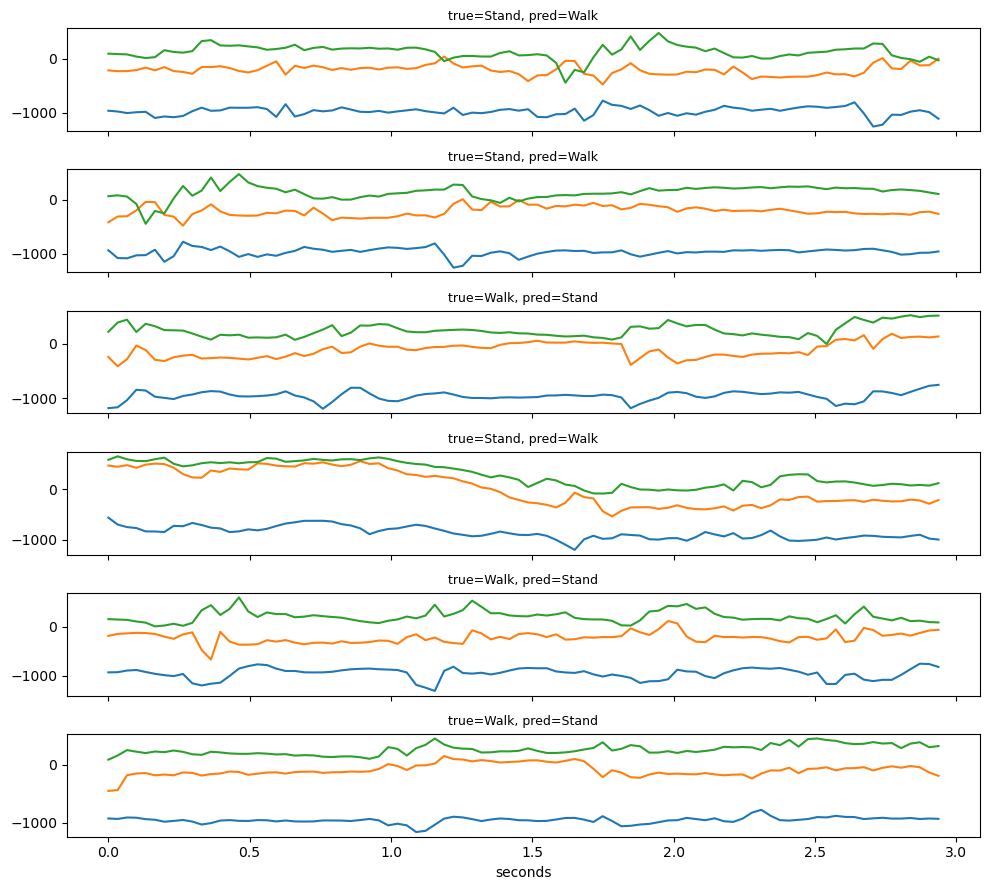

{'simplified_baseline_macro_f1': 0.958364222135148, 'source_baseline_macro_f1': 0.9701816601035093, 'source_lstm_macro_f1': 0.9085969197256405, 'error_windows': 23, 'boundary': 'source_run_id来自时间戳回退得到的采集运行，不等同于已知受试者编号。'}


In [6]:
wrong_local = np.where(test_pred != y[test_idx])[0]  # 找出测试集错误窗口
fig, axes = plt.subplots(min(6, len(wrong_local)), 1, figsize=(10, 9), sharex=True)  # 创建错误窗口图
axes = np.atleast_1d(axes)  # 保证只有一个错误时仍可循环
for axis, local_index in zip(axes, wrong_local[:len(axes)]):  # 显示最多六个错误样本
    absolute_index = test_idx[local_index]  # 转换为全部窗口中的索引
    axis.plot(np.arange(90) / 30.303, X[absolute_index, :, 0:3])  # 绘制背部三轴加速度
    axis.set_title(f"true={label_names[y[absolute_index]]}, pred={label_names[test_pred[local_index]]}", fontsize=9)  # 标注真实和预测类别
axes[-1].set_xlabel('seconds')  # 标注时间轴
fig.tight_layout()  # 调整子图间距
fig.savefig(OUT / 'task5_error_windows.png', dpi=160)  # 保存错误样本图
plt.show()  # 显示错误样本
result_summary = {  # 汇总当前基线与配套研究材料模型
    'simplified_baseline_macro_f1': test_metrics['macro_f1'],  # 记录当前五统计量基线
    'source_baseline_macro_f1': source_metrics['baseline_test_macro_f1'],  # 记录配套研究材料十四统计量基线
    'source_lstm_macro_f1': source_metrics['lstm_test_macro_f1'],  # 记录配套研究材料小型LSTM
    'error_windows': int(len(wrong_local)),  # 记录测试错误窗口数量
    'boundary': source_metrics['evidence_boundary'],  # 保留采集运行分组边界
}
(OUT / 'result_summary.json').write_text(json.dumps(result_summary, ensure_ascii=False, indent=2), encoding='utf-8')  # 保存结果摘要
print(result_summary)  # 显示模型比较
